In [1]:
import pandas as pd
import numpy as np

# Reading the data into a dataframe

df = pd.read_csv("SBAnational.csv", header= 0)

C:\Users\cnrzh\AppData\Local\Temp\ipykernel_32708\4277921081.py:6: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("SBAnational.csv", header= 0)


In [2]:
#Begin Exploratory Data analysis and Feature Engineering
print(f"Dataset Shape: {df.shape}")
print()
print(df.info())
print()
print(df.describe())
print()
print("Null values per column:\n", df.isna().sum())
print()
print("Number of duplicates:", df.duplicated().sum())

Dataset Shape: (899164, 27)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 899164 entries, 0 to 899163
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   LoanNr_ChkDgt      899164 non-null  int64  
 1   Name               899150 non-null  object 
 2   City               899134 non-null  object 
 3   State              899150 non-null  object 
 4   Zip                899164 non-null  int64  
 5   Bank               897605 non-null  object 
 6   BankState          897598 non-null  object 
 7   NAICS              899164 non-null  int64  
 8   ApprovalDate       899164 non-null  object 
 9   ApprovalFY         899164 non-null  object 
 10  Term               899164 non-null  int64  
 11  NoEmp              899164 non-null  int64  
 12  NewExist           899028 non-null  float64
 13  CreateJob          899164 non-null  int64  
 14  RetainedJob        899164 non-null  int64  
 15  FranchiseCode      899

In [3]:
#Handle missing values

#Some columns have so few missing values that we can drop the missing rows,
#without having a big impact on the dataset
df = df.dropna(subset = ["Name", 'City', "State", "MIS_Status"])

print(df["MIS_Status"].isna().sum())
#Other columns will have a "U" value added for unknown
df["Bank"].fillna("U", inplace=True)
df["BankState"].fillna("U", inplace=True)
df["RevLineCr"].fillna("U", inplace=True)
df["LowDoc"].fillna("U", inplace=True)

#Most rows in the columns have a null value for CHGOffDat. This is expected,
#as the value is only filled in for loans that have defaulted. Currently,
#we don't plan to use this column for our models, so we can leave it alone
#for now.

0


C:\Users\cnrzh\AppData\Local\Temp\ipykernel_32708\2961018742.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Bank"].fillna("U", inplace=True)
C:\Users\cnrzh\AppData\Local\Temp\ipykernel_32708\2961018742.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when 

In [4]:
#Pandas rasied a flag saying that column "ApprovalFY" has rows with different types.
print("Unique values for column ApprovalFY:", df["ApprovalFY"].unique())
#There are samples that store the year as a string instead of an int, and an outlier has the value "1976A"
#We will trim the letter A from the outlier, and convert all rows of this column to integers.
df["ApprovalFY"] = df["ApprovalFY"].astype(str).replace("1976A", "1976").astype(int)
print("Unique values for column ApprovalFY:", df["ApprovalFY"].unique())
print()

#For column FranchiseCode, both 00000 00001 signify no franchise, so we will condense them to 00000
df.loc[df["FranchiseCode"] == 1, "FranchiseCode"] = 0
print("Unique values for LowDoc", df["LowDoc"].unique())
#Column LowDoc is supposed to be simple binary values of "yes" or "no", but the list of values that occur
#is "Y", "N", "C", "1", "nan", "S", "R", "A", "0".
#There are approximately 4500 rows that contain values S, R, A, C, or nan
#For now, we will convert "1" to "Y", "0" to "N", and mark the other values
#as U for undefined
df.loc[df["LowDoc"] == "1", "LowDoc"] = "Y"
df.loc[df["LowDoc"] == "0", "LowDoc"] = "N"
df.loc[(df["LowDoc"] != "Y") & (df["LowDoc"] != "N"), "LowDoc"] = "U"
print("Unique values for LowDoc", df["LowDoc"].unique())
print()

print("Unique values in column NewExist", df["NewExist"].unique())
#Per the documentation, the column NewExist should store values
#{1 : Existing Business, 2: New Business}, but this column also contains
#missing values and 0 values.
#We are converted these values to "E", "N", and "U". This way they can later 
#be scaled with one hot encoding
df.loc[df["NewExist"] == 1.0, "NewExist"] = "E"
df.loc[df["NewExist"] == 2.0, "NewExist"] = "N"
df.loc[(df["NewExist"].isna()) | (df["NewExist"] == 0.0), "NewExist"] = "U"
print("Unique values in column NewExist", df["NewExist"].unique())
print()

print("Unique Values of RevLineCr", df["RevLineCr"].unique())
#This column should just be Y or N. We will map the values to Y, N and U for 
#undefined. Later than can be encoded with one hot encoding
df.loc[(df["RevLineCr"] != "Y") & (df["RevLineCr"] != "N"), "RevLineCr"] = "U"
print("Unique Values of RevLineCr", df["RevLineCr"].unique())

#Convert monetary columns DisbursementGross, BalanceGross, ChgOffPrinGr, 
#GrAppv and SBA_Appv from strings to floats
df["DisbursementGross"] = (
    df["DisbursementGross"].str.replace("$", "", regex = False)\
    .str.replace(",", "", regex = False)\
    .astype(float)
)
df["BalanceGross"] = (
    df["BalanceGross"].str.replace("$", "", regex = False)\
    .str.replace(",", "", regex = False)\
    .astype(float)
)
df["ChgOffPrinGr"] = (
    df["ChgOffPrinGr"].str.replace("$", "", regex = False)\
    .str.replace(",", "", regex = False)\
    .astype(float)
)
df["GrAppv"] = (
    df["GrAppv"].str.replace("$", "", regex = False)\
    .str.replace(",", "", regex = False)\
    .astype(float)
)
df["SBA_Appv"] = (
    df["SBA_Appv"].str.replace("$", "", regex = False)\
    .str.replace(",", "", regex = False)\
    .astype(float)
)

#There are samples that have values for State or BankState that are not one of the 50 states. These
#could represent US territories or clerical errors. They make up a small amount of the data set,
#so we will drop them.
states = [    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA",
    "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD",
    "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
    "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC",
    "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY"]

print(df[~df["State"].isin(states)]["State"].count())
print(df[~df["BankState"].isin(states)]["BankState"].count())
df = df[(df["State"].isin(states)) & (df["BankState"].isin(states))]
print(df[~df["State"].isin(states)]["State"].count())
print(df[~df["BankState"].isin(states)]["BankState"].count())

Unique values for column ApprovalFY: [1997 1980 2006 1998 1999 2000 2001 1972 2003 2004 1978 1979 1981 2005
 1982 1983 1973 1984 2007 1985 1986 1987 2008 1988 2009 1989 1991 1990
 1974 2010 2011 1992 1993 2002 2012 2013 1994 2014 1975 1977 1976 '2004'
 '1994' '1979' '1976' '1975' '1974' '1977' '1981' '1982' '1983' '1984'
 '1978' '1980' '1968' '1976A' '1969' '1995' '1970' '2005' '1996' '1971'
 1996 1971]
Unique values for column ApprovalFY: [1997 1980 2006 1998 1999 2000 2001 1972 2003 2004 1978 1979 1981 2005
 1982 1983 1973 1984 2007 1985 1986 1987 2008 1988 2009 1989 1991 1990
 1974 2010 2011 1992 1993 2002 2012 2013 1994 2014 1975 1977 1976 1968
 1969 1995 1970 1996 1971]

Unique values for LowDoc ['Y' 'N' 'C' '1' 'U' 'S' 'R' 'A' '0']
Unique values for LowDoc ['Y' 'N' 'U']

Unique values in column NewExist [ 2.  1.  0. nan]


C:\Users\cnrzh\AppData\Local\Temp\ipykernel_32708\3832883277.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'E' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["NewExist"] == 1.0, "NewExist"] = "E"


Unique values in column NewExist ['N' 'E' 'U']

Unique Values of RevLineCr ['N' '0' 'Y' 'T' 'U' '`' ',' '1' 'C' '3' '2' 'R' '7' 'A' '5' '.' '4' '-'
 'Q']
Unique Values of RevLineCr ['N' 'U' 'Y']
1613
5677
0
0


In [5]:
df["ApprovalDate"] = pd.to_datetime(df["ApprovalDate"], errors="coerce")

df = df[
    (df["ApprovalDate"] >= "2008-01-01") &
    (df["ApprovalDate"] <= "2010-12-31")
].copy()

C:\Users\cnrzh\AppData\Local\Temp\ipykernel_32708\223203377.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["ApprovalDate"] = pd.to_datetime(df["ApprovalDate"], errors="coerce")


In [6]:
#There are some additional features that can be extracted from this data set.

#ChgOffPinGr represents the gross amount of principal that was left on the
#loan after the lender placed it in default. SBA_Appv, is the amount that 
#the SBA guarantees in case of default. We can use these two  features to 
#calculate how much the SBA needed to reimburse the lender for each default.
df["SBA_payout"] = np.minimum(df["SBA_Appv"], df["ChgOffPrinGr"])

#The first two digits of the NAICS code indicate its industry. We will use
#this to create an Industry categorical variable.
exact_mapping = {
    11: "Agriculture, forestry, fishing and hunting",
    21: "Mining, quarrying, and oil and gas extraction",
    22: "Utilities",
    23: "Construction",
    42: "Wholesale trade",
    51: "Information",
    52: "Finance and insurance",
    53: "Real estate and rental and leasing",
    54: "Professional, scientific, and technical services",
    55: "Management of companies and enterprises",
    56: "Administrative and support and waste management and remediation services",
    61: "Educational services",
    62: "Health care and social assistance",
    71: "Arts, entertainment, and recreation",
    72: "Accommodation and food services",
    81: "Other services (except public administration)",
    92: "Public administration"
}
def map_naics(code):
    code = int(str(code)[:2])
    if 31 <= code <= 33:
        return "Manufacturing"
    elif 44 <= code <= 45:
        return "Retail trade"
    elif 48 <= code <= 49:
        return "Transportation and warehousing"
    else:
        return exact_mapping.get(code, "Unknown")
df["Industry"] = df["NAICS"].apply(map_naics)
print(df["Industry"].unique())

#Some features are unique identifiers that we don't expect to have a
#correlation with our targets. We will drop these.
#We will also drop ChgOffDate due to the high number of missing values
#and we will drop DisbursementDate and ApprovalDate, as ApprovalFY
#gives us all the time information that we need.
df = df.drop(columns = [
    "LoanNr_ChkDgt", "Name", "Bank", "ApprovalDate", "DisbursementDate",
    "ChgOffPrinGr",        # post-default info
    "ChgOffDate",          # also post-default
    "SBA_payout"           # derived from ChgOffPrinGr
])

['Real estate and rental and leasing'
 'Professional, scientific, and technical services' 'Retail trade'
 'Transportation and warehousing' 'Accommodation and food services'
 'Construction' 'Wholesale trade' 'Finance and insurance'
 'Administrative and support and waste management and remediation services'
 'Educational services' 'Information' 'Manufacturing'
 'Arts, entertainment, and recreation'
 'Other services (except public administration)'
 'Health care and social assistance'
 'Agriculture, forestry, fishing and hunting'
 'Mining, quarrying, and oil and gas extraction'
 'Management of companies and enterprises' 'Utilities'
 'Public administration' 'Unknown']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67038 entries, 270781 to 578591
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               67038 non-null  object 
 1   State              67038 non-null  object 
 2   Zip                67038 non-null  int64  
 3   BankState          67038 non-null  object 
 4   NAICS              67038 non-null  int64  
 5   ApprovalFY         67038 non-null  int64  
 6   Term               67038 non-null  int64  
 7   NoEmp              67038 non-null  int64  
 8   NewExist           67038 non-null  object 
 9   CreateJob          67038 non-null  int64  
 10  RetainedJob        67038 non-null  int64  
 11  FranchiseCode      67038 non-null  int64  
 12  UrbanRural         67038 non-null  int64  
 13  RevLineCr          67038 non-null  object 
 14  LowDoc             67038 non-null  object 
 15  DisbursementGross  67038 non-null  float64
 16  BalanceGross       67

In [8]:
df.head()

,City,State,Zip,BankState,NAICS,ApprovalFY,Term,NoEmp,NewExist,CreateJob,...,FranchiseCode,UrbanRural,RevLineCr,LowDoc,DisbursementGross,BalanceGross,MIS_Status,GrAppv,SBA_Appv,Industry
270781,ELMHURST,NY,11373,NC,532220,2008,49,5,N,0,...,0,1,N,N,75000.0,0.0,CHGOFF,75000.0,37500.0,Real estate and rental and leasing
270783,SCOTTSDALE,AZ,85259,IL,541330,2008,84,5,N,0,...,0,1,Y,N,56867.0,0.0,P I F,25000.0,12500.0,"Professional, scientific, and technical services"
270785,Brentwood,CA,94513,CA,453220,2008,88,0,N,4,...,0,1,N,N,355000.0,0.0,CHGOFF,355000.0,266250.0,Retail trade
270788,Lawrenceville,GA,30044,GA,485320,2008,48,1,E,2,...,0,1,Y,N,30525.0,0.0,P I F,15000.0,7500.0,Transportation and warehousing
270790,Blue Springs,MO,64015,CA,722211,2008,124,10,N,0,...,0,1,N,N,369000.0,0.0,P I F,369000.0,276750.0,Accommodation and food services


In [9]:
print("Count of PIF samples: ", df[df["MIS_Status"] == "P I F"]["MIS_Status"].count())
print("Count of CHGOFF samples: ", df[df["MIS_Status"] == "CHGOFF"]["MIS_Status"].count())

Count of PIF samples:  50424
Count of CHGOFF samples:  16614


In [10]:

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.ensemble import HistGradientBoostingClassifier  

# For display
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

target_col = "MIS_Status"
zip_col = "Zip"
industry_col = "Industry"
status_map = {
    "CHGOFF": 1,
    "P I F": 0
}

df = df[df[target_col].isin(status_map.keys())].copy()
df["target"] = df[target_col].map(status_map).astype(int)

df[zip_col] = df[zip_col].astype(str).str.zfill(5)

df["target"].value_counts(normalize=True)




target
0    0.75217
1    0.24783
Name: proportion, dtype: float64

In [11]:
drop_cols = [
    target_col,
    zip_col,
    "LoanNr_ChkDgt", "Name", "City", "State",
    "BankState",
    "ApprovalDate", "DisbursementDate", "ChgOffDate"
]

drop_cols_ind = [
    target_col,
    industry_col,
    "LoanNr_ChkDgt", "Name", "City", "State",
    "BankState",
    "ApprovalDate", "DisbursementDate", "ChgOffDate"
]

drop_cols = [c for c in drop_cols if c in df.columns]

drop_cols_ind = [c for c in drop_cols_ind if c in df.columns]

feature_cols = [c for c in df.columns if c not in drop_cols + ["target"]]

feature_cols_ind = [c for c in df.columns if c not in drop_cols_ind + ["target"]]

X = df[feature_cols]
X2 = df[feature_cols_ind]
y = df["target"]
y2 = df["target"]

In [12]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_features, categorical_features

(['NAICS',
  'ApprovalFY',
  'Term',
  'NoEmp',
  'CreateJob',
  'RetainedJob',
  'FranchiseCode',
  'UrbanRural',
  'DisbursementGross',
  'BalanceGross',
  'GrAppv',
  'SBA_Appv'],
 ['NewExist', 'RevLineCr', 'LowDoc', 'Industry'])

In [13]:
numeric_features2 = X2.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features2 = X2.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_features2, categorical_features2

(['NAICS',
  'ApprovalFY',
  'Term',
  'NoEmp',
  'CreateJob',
  'RetainedJob',
  'FranchiseCode',
  'UrbanRural',
  'DisbursementGross',
  'BalanceGross',
  'GrAppv',
  'SBA_Appv'],
 ['Zip', 'NewExist', 'RevLineCr', 'LowDoc'])

In [14]:
from sklearn.pipeline import Pipeline

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

gb_clf = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=None,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    random_state=RANDOM_STATE
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("gb", gb_clf)
])


In [16]:
from sklearn.pipeline import Pipeline

preprocess2 = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features2),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features2),
    ]
)

gb_clf2 = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=None,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    random_state=RANDOM_STATE
)

model2 = Pipeline(steps=[
    ("preprocess", preprocess2),
    ("gb", gb_clf2)
])


In [17]:
print("len(df):", len(df))
print("len(X):", len(X))
print("len(y):", len(y))
print("len(zip series):", len(df[zip_col]))

len(df): 67038
len(X): 67038
len(y): 67038
len(zip series): 67038


In [18]:
X_train, X_test, y_train, y_test, zip_train, zip_test = train_test_split(
    X, y, df[zip_col],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

model.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('gb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
X2_train, X2_test, y_train2, y_test2, industry_train, industry_test = train_test_split(
    X2, y2, df[industry_col],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y2
)

model2.fit(X2_train, y_train2)


,steps,"[('preprocess', ...), ('gb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
# Predict on ALL loans
df["pred_default_proba"] = model.predict_proba(X)[:, 1]
df["actual_default"] = df["target"]

# Aggregate by ZIP
min_loans = 50  # or 20, depending on how noisy you can tolerate

zip_stats = (
    df.groupby(zip_col)
      .agg(
          n_loans=("target", "size"),
          actual_default_rate=("actual_default", "mean"),
          avg_pred_default=("pred_default_proba", "mean")
      )
      .reset_index()
)

# Filter to ZIPs with enough data
zip_stats = zip_stats[zip_stats["n_loans"] >= min_loans].copy()

# Define a resilience score: higher = more resilient
zip_stats["resilience_score"] = 1 - zip_stats["avg_pred_default"]

zip_stats.sort_values("resilience_score", ascending=False).head(20)


,Zip,n_loans,actual_default_rate,avg_pred_default,resilience_score
5631,39051,54,0.037037,0.130675,0.869325
12060,84321,50,0.180000,0.136630,0.863370
13205,93401,77,0.129870,0.161616,0.838384
8648,58103,56,0.142857,0.165345,0.834655
12007,84078,62,0.193548,0.168236,0.831764
8777,59714,60,0.150000,0.188534,0.811466
12035,84115,51,0.235294,0.223860,0.776140
11980,84041,50,0.260000,0.224190,0.775810
12021,84095,65,0.261538,0.246288,0.753712
12031,84107,57,0.280702,0.267271,0.732729


In [22]:
# Predict on ALL loans
df["pred_default_proba"] = model2.predict_proba(X2)[:, 1]
df["actual_default"] = df["target"]

# Aggregate by Industry
min_loans = 20

industry_stats = (
    df.groupby(industry_col)
      .agg(
          n_loans=("target", "size"),
          actual_default_rate=("actual_default", "mean"),
          avg_pred_default=("pred_default_proba", "mean")
      )
      .reset_index()
)

# Filter to ZIPs with enough data
industry_stats = industry_stats[industry_stats["n_loans"] >= min_loans].copy()

# Define a resilience score: higher = more resilient
industry_stats["resilience_score"] = 1 - industry_stats["avg_pred_default"]

industry_stats.sort_values("resilience_score", ascending=False).head(20)


,Industry,n_loans,actual_default_rate,avg_pred_default,resilience_score
2,"Agriculture, forestry, fishing and hunting",1042,0.094050,0.121994,0.878006
7,Health care and social assistance,5753,0.126543,0.142979,0.857021
11,"Mining, quarrying, and oil and gas extraction",221,0.104072,0.143766,0.856234
10,Manufacturing,6008,0.196072,0.205720,0.794280
20,Wholesale trade,3991,0.247557,0.242429,0.757571
5,Educational services,873,0.265750,0.247354,0.752646
17,Transportation and warehousing,3055,0.238625,0.253618,0.746382
1,Administrative and support and waste managemen...,3317,0.255954,0.254510,0.745490
0,Accommodation and food services,7243,0.264945,0.254822,0.745178
13,"Professional, scientific, and technical services",7812,0.253968,0.256221,0.743779


In [23]:
zip_stats.describe()
zip_stats.sort_values("actual_default_rate").head(20)

,Zip,n_loans,actual_default_rate,avg_pred_default,resilience_score
5631,39051,54,0.037037,0.130675,0.869325
13205,93401,77,0.129870,0.161616,0.838384
8648,58103,56,0.142857,0.165345,0.834655
8777,59714,60,0.150000,0.188534,0.811466
12060,84321,50,0.180000,0.136630,0.863370
12007,84078,62,0.193548,0.168236,0.831764
12035,84115,51,0.235294,0.223860,0.776140
11980,84041,50,0.260000,0.224190,0.775810
12021,84095,65,0.261538,0.246288,0.753712
12600,90021,57,0.263158,0.270138,0.729862


In [24]:
industry_stats.describe()
industry_stats.sort_values("actual_default_rate").head(20)

,Industry,n_loans,actual_default_rate,avg_pred_default,resilience_score
2,"Agriculture, forestry, fishing and hunting",1042,0.094050,0.121994,0.878006
11,"Mining, quarrying, and oil and gas extraction",221,0.104072,0.143766,0.856234
7,Health care and social assistance,5753,0.126543,0.142979,0.857021
10,Manufacturing,6008,0.196072,0.205720,0.794280
17,Transportation and warehousing,3055,0.238625,0.253618,0.746382
20,Wholesale trade,3991,0.247557,0.242429,0.757571
13,"Professional, scientific, and technical services",7812,0.253968,0.256221,0.743779
1,Administrative and support and waste managemen...,3317,0.255954,0.254510,0.745490
0,Accommodation and food services,7243,0.264945,0.254822,0.745178
5,Educational services,873,0.265750,0.247354,0.752646


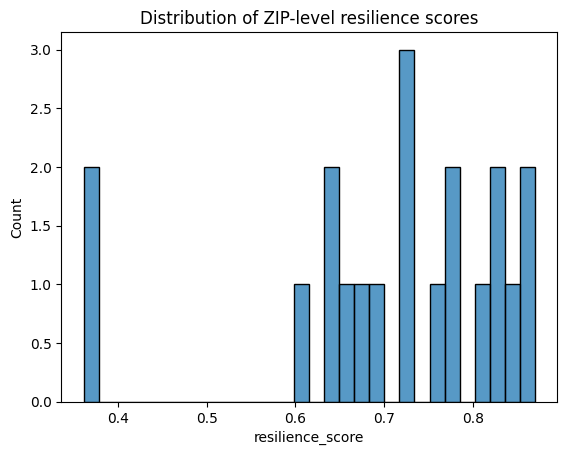

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(zip_stats["resilience_score"], bins=30)
plt.title("Distribution of ZIP-level resilience scores")
plt.show()

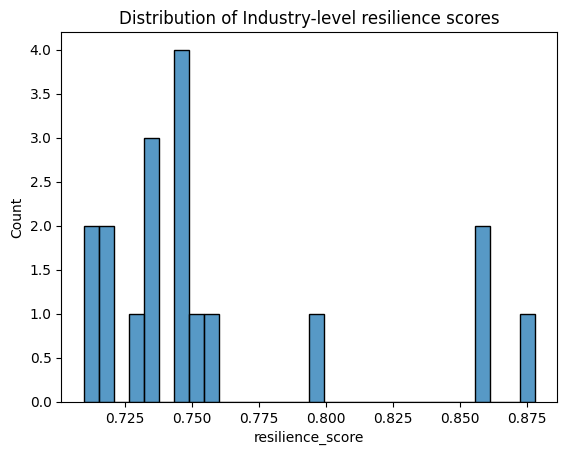

In [26]:
sns.histplot(industry_stats["resilience_score"], bins=30)
plt.title("Distribution of Industry-level resilience scores")
plt.show()

In [27]:
zip_stats = (
    df.groupby(zip_col)
      .agg(
          n_loans=("target", "size"),
          avg_pred_default=("pred_default_proba", "mean")
      )
      .reset_index()
)
zip_stats["resilience_score"] = 1 - zip_stats["avg_pred_default"]

In [28]:
zip_stats[zip_col] = zip_stats[zip_col].astype(str).str.zfill(5)

In [29]:
import geopandas as gpd

zcta = gpd.read_file("shapedata/tl_2020_us_zcta510.shp")

zcta = zcta.rename(columns={"ZCTA5CE10": "ZIP"})
zcta["ZIP"] = zcta["ZIP"].astype(str).str.zfill(5)

zcta.head()


,ZIP,GEOID10,CLASSFP10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,geometry
0,43451,43451,B5,G6350,S,63484189,157689,+41.3183193,-083.6150363,"POLYGON ((-83.70873 41.32733, -83.70815 41.327..."
1,43452,43452,B5,G6350,S,121525288,13721740,+41.5202297,-082.9770334,"POLYGON ((-83.08698 41.5378, -83.08256 41.5377..."
2,43456,43456,B5,G6350,S,9320978,1003775,+41.6318300,-082.8393923,"MULTIPOLYGON (((-82.83558 41.71082, -82.83515 ..."
3,43457,43457,B5,G6350,S,48004678,0,+41.2673301,-083.4274872,"POLYGON ((-83.4965 41.25371, -83.48382 41.2537..."
4,43458,43458,B5,G6350,S,2573816,39915,+41.5304461,-083.2133648,"POLYGON ((-83.22229 41.53102, -83.22228 41.532..."


In [30]:
zip_map = zcta.merge(zip_stats, left_on="ZIP", right_on=zip_col, how="left")


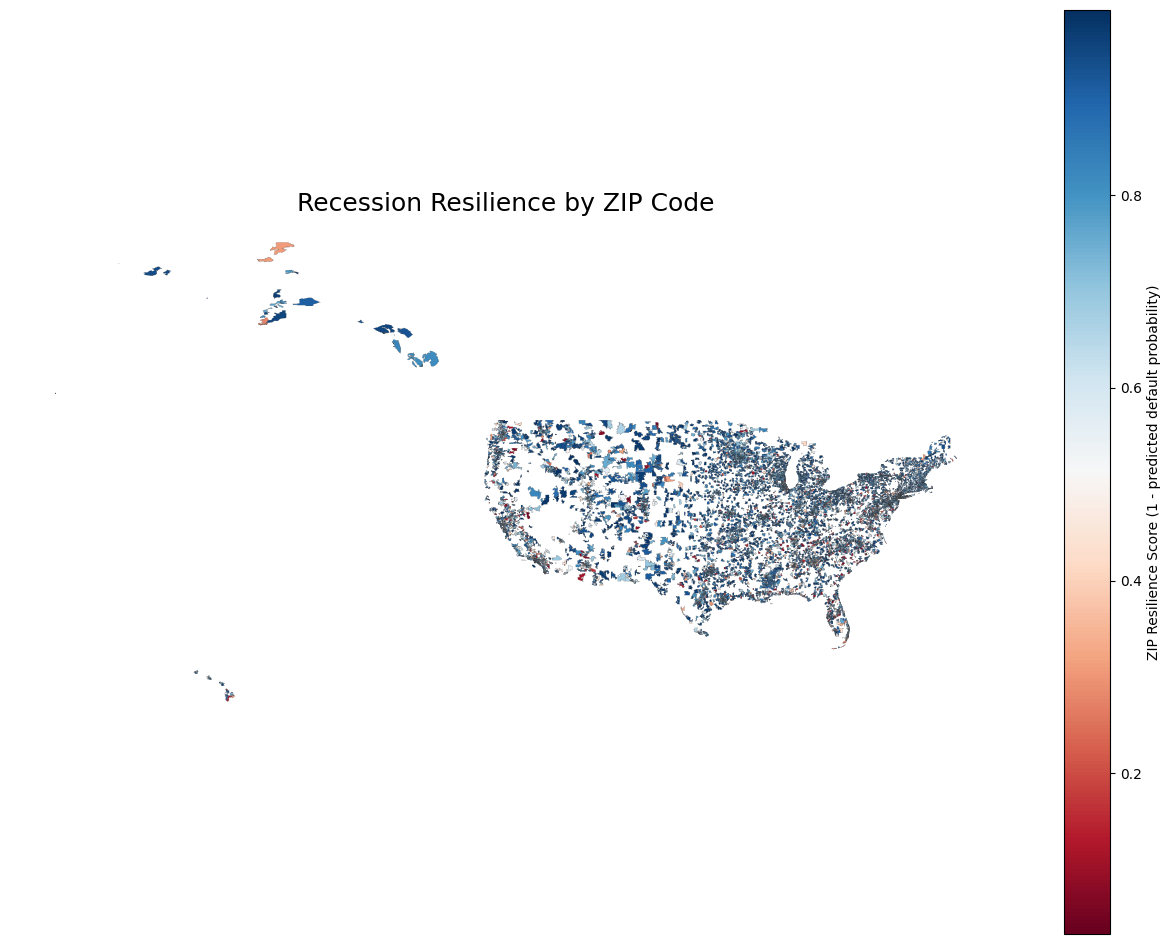

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(16, 12))

zip_map.plot(
    column="resilience_score",
    cmap="RdBu",
    linewidth=0.1,
    ax=ax,
    edgecolor="0.2",
    legend=True,
    legend_kwds={"label": "ZIP Resilience Score (1 - predicted default probability)"}
)

ax.set_title("Recession Resilience by ZIP Code", fontsize=18)
ax.axis("off")
plt.show()


In [32]:
from sklearn.model_selection import train_test_split

# First split: Train vs Temp (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,       # 70% train, 30% temp
    random_state=42,
    stratify=y
)

# Second split: Validation vs Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,       # Half of 30% → 15% validation, 15% test
    random_state=42,
    stratify=y_temp
)

len(X_train), len(X_val), len(X_test)


(46926, 10056, 10056)

In [33]:
model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('gb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
from sklearn.metrics import roc_auc_score, classification_report

y_val_proba = model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_proba > 0.5).astype(int)

print("Validation ROC-AUC:", roc_auc_score(y_val, y_val_proba))
print(classification_report(y_val, y_val_pred))


Validation ROC-AUC: 0.9678647504908355
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7564
           1       0.87      0.82      0.85      2492

    accuracy                           0.93     10056
   macro avg       0.91      0.89      0.90     10056
weighted avg       0.92      0.93      0.92     10056



In [35]:
y_test_proba = model.predict_proba(X_test)[:, 1]
print("Final Test ROC-AUC:", roc_auc_score(y_test, y_test_proba))

Final Test ROC-AUC: 0.9683160624840313


In [36]:
from sklearn.model_selection import train_test_split

# First split: Train vs Temp (Validation + Test)
X2_train, X2_temp, y_train2, y_temp2 = train_test_split(
    X2, y2,
    test_size=0.3,       # 70% train, 30% temp
    random_state=42,
    stratify=y2
)

# Second split: Validation vs Test
X2_val, X2_test, y_val2, y_test2 = train_test_split(
    X2_temp, y_temp2,
    test_size=0.5,       # Half of 30% → 15% validation, 15% test
    random_state=42,
    stratify=y_temp2
)


In [37]:
model2.fit(X2_train, y_train2)

,steps,"[('preprocess', ...), ('gb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [38]:
from sklearn.metrics import roc_auc_score, classification_report

y_val_proba = model2.predict_proba(X2_val)[:, 1]
y_val_pred = (y_val_proba > 0.5).astype(int)

print("Validation ROC-AUC:", roc_auc_score(y_val2, y_val_proba))
print(classification_report(y_val2, y_val_pred))


ValueError: columns are missing: {'Industry'}

In [ ]:
df[industry_col] = df[industry_col].astype(str)

In [ ]:
industry_stats = (
    df.groupby(industry_col)
      .agg(
          n_loans=("target", "size"),
          actual_default_rate=("target", "mean"),
          avg_pred_default=("pred_default_proba", "mean")
      )
      .reset_index()
)

industry_stats["resilience_score"] = 1 - industry_stats["avg_pred_default"]

industry_stats.head()


In [ ]:
industry_stats

In [ ]:
industry_stats = industry_stats[industry_stats["n_loans"] >= 50]

In [ ]:
industry_stats

In [ ]:
plt.figure(figsize=(12, 25))

sns.barplot(
    data=industry_stats.sort_values("resilience_score", ascending=False),
    x="resilience_score",
    y=industry_col,
    palette="RdBu"
)

plt.title("Industry Resilience Ranking")
plt.xlabel("Resilience (1 - avg predicted default)")
plt.ylabel("Industry (NAICS)")
plt.show()